
# MulensModel Crash Course Using Real Microlensing Data

This notebook demonstrates what **MulensModel actually does** using real observational datasets distributed with MulensModel.

## Purpose and scope: 
This notebook is a guided reproduction and explanation of official MulensModel tutorials using published microlensing datasets and model parameters. Its purpose is to become familiar with the package’s data structures, light-curve calculations, fitting workflow, and higher-order effects. It is not an independent planet-discovery analysis.

You will work through five examples:

1. Load and inspect real telescope data.
2. Fit a simple point-lens model to real observations.
3. Compare a one-lens model against a star + planet model.
4. Combine observations from multiple telescopes and examine finite-source effects.
5. Compare models with and without annual microlensing parallax.

## The basic workflow

```text
telescope measurements
        ↓
MulensData stores the observations
        ↓
Model calculates a theoretical microlensing light curve
        ↓
Event connects the model and observations
        ↓
MulensModel calculates chi-squared and residuals
        ↓
an optimizer searches for better model parameters
```

## Data sources

The files used below are distributed in MulensModel's `DATA_PATH`.

- **OB08092 / OGLE-2008-BLG-092:** used by the official MulensModel fitting tutorial. The OGLE project describes the full event as a triple-lens system containing a cold Uranus-like planet.  
  MulensModel tutorial: https://rpoleski.github.io/MulensModel/tutorial_fit_pspl.html  
  OGLE event page: https://ogle.astrouw.edu.pl/cont/4_main/epl/ob08092/

- **OGLE-2003-BLG-235 / MOA-2003-BLG-53:** used by the official basic tutorial, which states that the data came from the NASA Exoplanet Archive. This event was the first microlensing planet discovery!  
  https://rpoleski.github.io/MulensModel/tutorial.html

- **MOA-2008-BLG-310:** the official MulensModel example attributes these observations and model parameters to Janczak et al. (2010), *ApJ*, 711, 731.  
  https://github.com/rpoleski/MulensModel/blob/master/examples/example_05_MB08310.py

- **OGLE-2005-BLG-086:** used in the official annual-parallax tutorial and identified there as event 3291 from Wyrzykowski et al. (2015).  
  https://rpoleski.github.io/MulensModel/tutorial_fit_pi_E.html



# 0. Setup and check the installation

Run the next cell first.

`mm.DATA_PATH` is the folder in your MulensModel installation that contains the example observational files.


In [1]:
# Path makes it easier to create and work with file and folder paths.
from pathlib import Path

# shutil contains file-copying tools.
import shutil

# urllib.request lets Python download files from a URL.
import urllib.request

# zipfile lets Python open and extract ZIP archives.
import zipfile

# Import MulensModel so we can check its version and update the location where it looks for example data.
import MulensModel as mm


# 1. Decide where the example data will be stored
# Store the tutorial data beside this notebook.
data_folder = Path.cwd() / f"mulensmodel-v{mm.__version__}-data"

# 2. Choose one known file to check whether the data exist
test_file = (
    data_folder
    / "photometry_files"
    / "OB08092"
    / "phot_ob08092_O4.dat"
)

# 3. Download the release only when the data is missing (not present).
if not test_file.exists():
    # Read the installed MulensModel version.
    # On your computer, this should be "3.11.0".
    version = mm.__version__

    # This is the temporary ZIP file that will be downloaded.
    zip_file = Path.cwd() / f"MulensModel-v{version}.zip"

    # This is the GitHub URL for the source-code ZIP file corresponding to the installed MulensModel version.
    download_url = (
        "https://github.com/rpoleski/MulensModel/"
        f"archive/refs/tags/v{version}.zip"
    )

    # Inside the ZIP archive, the data files begin inside a folder with a name such as:
    # MulensModel-3.11.0/data/
    archive_data_prefix = f"MulensModel-{version}/data/"

    print("Downloading the MulensModel example data...")

    # Download the ZIP file from GitHub and save it to zip_file.
    urllib.request.urlretrieve(download_url, zip_file)

    # Keep track of how many files were extracted.
    files_extracted = 0

    # Open the downloaded ZIP archive.
    with zipfile.ZipFile(zip_file, "r") as archive:
        #Go through every item inside the ZIP archive.
        for file_info in archive.infolist():

           
            #Skip folders and anything outside the data directory.
            #We only want actual files
            if file_info.is_dir():
                continue

            # Skip anything that is not inside the archive's main data folder.
            if not file_info.filename.startswith(archive_data_prefix):
                continue

            # Remove "MulensModel-3.11.0/data/" from the archive path.
            relative_name = file_info.filename[
                len(archive_data_prefix):
            ]

            # Create the complete destination path on your computer.
            destination = data_folder / relative_name

            # Create any required parent folders.
            # parents=True:
            # Create all missing folders in the path
            # exist_ok=True:
            # Do not give an error if a folder already exists.
            destination.parent.mkdir(
                parents=True,
                exist_ok=True
            )

            # Open the file inside the ZIP archive.
            with archive.open(file_info) as source:
                # Create the corresponding file on your computer.
                with open(destination, "wb") as output:
                    # Copy the contents of the archived file into the new file on your computer.
                    shutil.copyfileobj(source, output)

            # Add 1 to the extracted-file counter.
            files_extracted += 1

    # The ZIP is no longer needed after extraction.
    # Delete the temporary ZIP file after extraction.
    # The actual data files remain in data_folder.
    # missing_ok=True means no error is raised if the ZIP file is already missing.
    zip_file.unlink(missing_ok=True)

    # Raise an error if the ZIP downloaded but no data files were found or extracted. 
    if files_extracted == 0:
        raise RuntimeError(
            "The download completed, but no data files were found."
        )

    print(f"Extracted {files_extracted} data files.")

# This runs when the test file already exists.
# It prevents the notebook from downloading everything again.
else:
    print( "MulensModel data folder:", Path(mm.DATA_PATH).name)


# 4. Tell MulensModel where the downloaded data are located
# Convert the Path object into a complete absolute path, then store that location in MulensModel's DATA_PATH variable.
mm.DATA_PATH = str(data_folder.resolve())

# 5. Check that everything worked
print("\nMulensModel data folder:", Path(mm.DATA_PATH).name)
print("Does the data folder exist?", Path(mm.DATA_PATH).is_dir())
print("Does the test dataset exist?", test_file.is_file())

MulensModel data folder: data

MulensModel data folder: mulensmodel-v3.11.0-data
Does the data folder exist? True
Does the test dataset exist? True


In [3]:

# glob helps search for groups of files whose names match a pattern.
# Later in the notebook, we use it to find all telescope data files ending in ".tbl" inside a folder.
import glob

# os provides tools for working with files, folders, and file paths.
# We use os.path.join() to build paths and os.path.isdir() to check whether a folder exists.
import os

# matplotlib.pyplot is used to create graphs.
# "as plt" gives it the shorter nickname plt.
import matplotlib.pyplot as plt

# NumPy is used for numerical calculations and arrays.
# "as np" gives it the shorter nickname np.
import numpy as np

# scipy.optimize contains optimization tools.
# Later, we use it to search for microlensing parameters that give the best fit to the observational data.
import scipy.optimize as optimize

# MulensModel calculates microlensing light curves, stores observational data, and compares models with data.
# "as mm" gives it the shorter nickname mm.
import MulensModel as mm

# Print the installed MulensModel version.
# This confirms which version of the package the notebook is using.
print("MulensModel version:", mm.__version__)

# Print the folder where MulensModel will look for its example observational datasets.
print("MulensModel data folder:", Path(mm.DATA_PATH).name)

# Check whether the data folder actually exists.
# os.path.isdir() returns True if the path is a real folder
# and False if the folder cannot be found.
print("Does the data folder exist?", os.path.isdir(mm.DATA_PATH))


MulensModel version: 3.11.0
MulensModel data folder: mulensmodel-v3.11.0-data
Does the data folder exist? True



The next cell checks whether the five datasets used in this notebook exist on your computer.


In [4]:
# Create a dictionary containing the file paths for the datasets that will be used later in the notebook.
# Each dictionary entry has:
#   key   = a short name for the dataset
#   value = the complete path to the corresponding data file


required_paths = {
    # Real photometry file for the OB08092 example.
    "OB08092":
        os.path.join(
            # Begin inside the MulensModel data folder,
            # then move through the required subfolders to reach the observational data file.
            mm.DATA_PATH, "photometry_files", "OB08092",
            "phot_ob08092_O4.dat"
        ),

    # OGLE telescope observations for
    # OGLE-2003-BLG-235 / MOA-2003-BLG-53.
    "OB03235 OGLE":
        os.path.join(
            mm.DATA_PATH, "photometry_files", "OB03235",
            "OB03235_OGLE.tbl.txt"
        ),

    # MOA telescope observations for the same microlensing event.
    "OB03235 MOA":
        os.path.join(
            mm.DATA_PATH, "photometry_files", "OB03235",
            "OB03235_MOA.tbl.txt"
        ),

    # Observations for the OGLE-2005-BLG-086
    # annual-parallax example.
    "OB05086":
        os.path.join(
            mm.DATA_PATH, "photometry_files", "OB05086",
            "starBLG234.6.I.218982.dat"
        ),
}


# Go through every dataset name and file path stored in the required_paths dictionary.
for name, path in required_paths.items():

    # os.path.exists(path) checks whether the file exists.
    #
    # It returns:
    #   True  if Python can find the file
    #   False if the file is missing
    #
    # {name:15s} gives the dataset name a width of 15 characters, which keeps the printed output aligned.
    
    print(f"{name:15s}: {os.path.exists(path)}")


# Search for all files ending in ".tbl" inside the MB08310 folder.
# The * symbol is a wildcard, meaning:
# "match any filename that ends in .tbl"
mb08310_files = sorted(
    glob.glob(
        os.path.join(
            mm.DATA_PATH, "photometry_files", "MB08310", "*.tbl"
        )
    )
)

# glob.glob() returns a list of all matching file paths.
# sorted() puts those paths into alphabetical order so that the output is consistent and easier to read.

# Print a blank line, followed by the number of telescope files found.
#
# len(mb08310_files) counts how many paths are in the list.
print("\nMB08310 telescope files found:", len(mb08310_files))
# Go through each telescope file that was found.
for path in mb08310_files:
    # os.path.basename(path) removes the folder information and prints only the filename.
    # For example:
    #/path/to/data/MB08310/Auck_0300089_PLC_001.tbl
    # becomes:
    # Auck_0300089_PLC_001.tbl
    print("   ", os.path.basename(path))



#In Summary, this cell does 2 checks:
#Check 1:
#Look for four specific files needed by later examples.

#Check 2:
#Look for every .tbl telescope file inside the MB08310 folder.


OB08092        : True
OB03235 OGLE   : True
OB03235 MOA    : True
OB05086        : True

MB08310 telescope files found: 7
    Auck_0300089_PLC_001.tbl
    Bron_0300089_PLC_002.tbl
    CTIO_H_0300089_PLC_004.tbl
    CTIO_I_0300089_PLC_005.tbl
    Canopus_0300089_PLC_003.tbl
    Danish_0300089_PLC_006.tbl
    MOA_0300089_PLC_007.tbl



# Example 1 — Load and plot real telescope measurements

## What this demonstrates

This example uses `MulensData` to read an observational file.

At this stage, MulensModel is **not yet calculating a theoretical lens model**. It is only:

1. Reading the observation times.
2. Reading the measured magnitudes.
3. Reading the measurement uncertainties.
4. Storing them in a useful microlensing-data object.

The data file is the one used by MulensModel's official basic fitting tutorial.


In [5]:

# Build the complete file path for the OB08092 observational dataset.
# os.path.join() safely combines folder names into one path.
# mm.DATA_PATH is the main folder containing the downloaded MulensModel example data.
ob08092_file = os.path.join(
    mm.DATA_PATH,
    "photometry_files",
    "OB08092",
    "phot_ob08092_O4.dat"
)

# Load the observational data file into a MulensData object.
# MulensData reads and stores:
# - observation times
# - measured magnitudes
# - magnitude uncertainties
# file_name tells MulensModel which file to read.
ob08092_data = mm.MulensData(file_name=ob08092_file)

# Count how many observations are contained in the dataset.
#
# ob08092_data.time is an array containing all observation times.
# len() returns the number of entries in that array.
print("Number of observations:", len(ob08092_data.time))

# Print a heading before displaying the first five observation times.
# \n adds a blank line before the heading.
print("\nFirst five observation times:")

# Display the first five values in the time array.
# [:5] means:
# start at the beginning and stop before index 5.
# This returns entries 0, 1, 2, 3, and 4.
print(ob08092_data.time[:5])

# Print a heading before displaying the first five measured magnitudes.
print("\nFirst five measured magnitudes:")

# Display the first five brightness measurements.
# In astronomy, magnitude is a brightness scale where
# smaller magnitude values mean brighter objects.
print(ob08092_data.mag[:5])

# Print a heading before displaying the first five uncertainties.
print("\nFirst five magnitude uncertainties:")

# Display the uncertainty associated with each of the
# first five magnitude measurements.
# A smaller uncertainty means the measurement is more precise.
print(ob08092_data.err_mag[:5])


Number of observations: 383

First five observation times:
[5264.841   5268.77925 5271.77332 5273.7826  5277.77071]

First five measured magnitudes:
[13.939 13.932 13.927 13.935 13.943]

First five magnitude uncertainties:
[0.0068 0.0068 0.0068 0.0068 0.0068]



Now plot the telescope measurements.

Each dot is one observation. The vertical error bar represents the reported uncertainty.

Astronomical magnitudes run backward: a **smaller magnitude means a brighter source**, so the vertical axis is inverted.


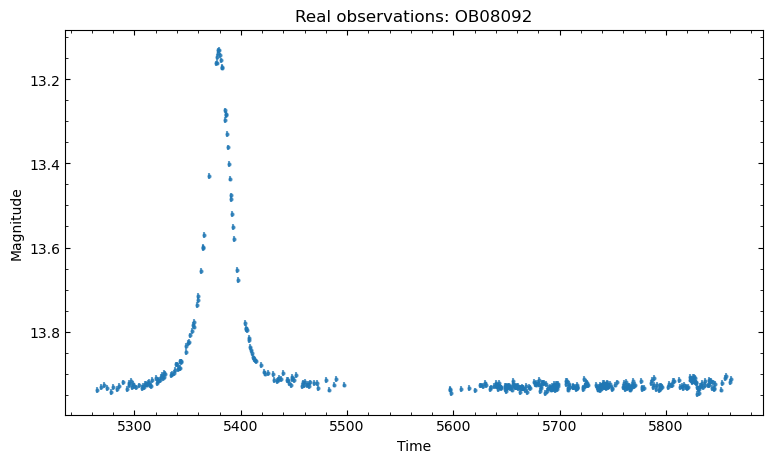

In [6]:
# Create a new plotting area.
# figsize=(9, 5) sets the width and height of the figure in inches.

plt.figure(figsize=(9, 5))

# Plot the real observations with vertical error bars.
plt.errorbar(
    # x-values: the observation times.
    ob08092_data.time,
    # y-values: the measured magnitudes.
    ob08092_data.mag,
    # yerr gives the uncertainty for each magnitude measurement.
    # These values determine the lengths of the vertical error bars.
    yerr=ob08092_data.err_mag,
    # fmt="." displays each observation as a small dot.
    fmt=".",
    # Set the size of each plotted point.
    markersize=4,
    # alpha controls transparency.
    # 1.0 is fully opaque, while 0.0 is fully transparent.
    alpha=0.7,
)

# Reverse the vertical axis.
# Astronomical magnitudes work backward:
# smaller magnitude = brighter object.
# Inverting the y-axis places brighter measurements higher on the graph, which is the standard astronomical convention.

plt.gca().invert_yaxis()

# Label the horizontal axis.
plt.xlabel("Time")

# Label the vertical axis.
plt.ylabel("Magnitude")

# Add a title describing the dataset.
plt.title("Real observations: OB08092")

# Display the finished graph.
plt.show()



## What MulensModel did here

It converted a text file into a `MulensData` object with accessible arrays:

```python
ob08092_data.time
ob08092_data.mag
ob08092_data.err_mag
```

This is the **data-storage part** of MulensModel.



# Example 2 — Fit a point-source, point-lens model

## What this demonstrates

Now we use MulensModel for its main scientific purpose:

> Given trial microlensing parameters, calculate the predicted light curve and its disagreement with the observations.

We begin with rough guesses:

- `t_0`: time of closest alignment
- `u_0`: minimum lens-source separation in Einstein-radius units
- `t_E`: Einstein crossing timescale in days

These starting values come from the official MulensModel fitting tutorial.


In [7]:
# Create a dictionary containing our initial guesses for the
# three parameters of a point-source, point-lens microlensing model.
#
# These are only starting guesses. Later, the optimizer will adjust
# them to find values that fit the observations better.

starting_parameters = {
    # t_0 is the time when the foreground lens passes closest to the background source star.
    # This should be close to the time of maximum brightness.
    "t_0": 5380.0,

    # u_0 is the minimum projected separation between the lens and source, measured in units of the Einstein radius.
    # A smaller u_0 generally produces a higher magnification.
    "u_0": 0.5,

    # t_E is the Einstein crossing time, measured in days.
    # It controls the approximate duration or width of the event.
    "t_E": 20.0,
}

# Create a theoretical point-source, point-lens model using the starting parameters above.
# PSPL stands for:
# Point-Source, Point-Lens
# At this stage, the model calculates what the microlensing magnification should look like for these assumed parameters.
pspl_model = mm.Model(starting_parameters)

# Create an Event object that connects:
# 1. The real telescope observations stored in ob08092_data
# 2. The theoretical microlensing model stored in pspl_model
# The datasets argument must be a list because one event can contain observations from several telescopes.
ob08092_event = mm.Event(
    datasets=[ob08092_data],
    model=pspl_model,
)

# Display the parameters currently stored in the model.
# This lets us confirm that MulensModel received the values
# t_0 = 5380.0, u_0 = 0.5, and t_E = 20.0.
print(pspl_model.parameters)


#In summary, the flow is:
    #starting parameter guesses
              #↓
    #create theoretical PSPL model
              #↓
    #connect the model to real observations
              #↓
    #prepare to compare prediction with data

    t_0 (HJD)       u_0    t_E (d) 
   5380.00000  0.500000    20.0000 



`Model` calculates the theoretical microlensing magnification.

`Event` connects that theoretical model to the real observations and fits the source and blended fluxes needed to put the model on the same brightness scale as the data.


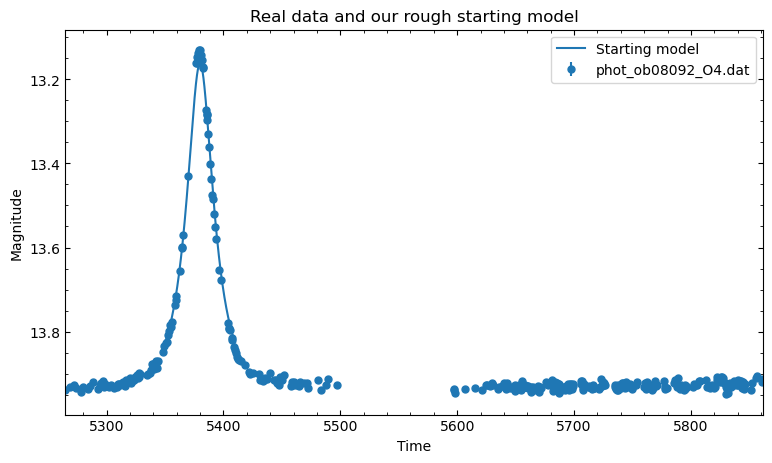

Starting chi-squared: 881.6627837869505


In [8]:
# Create a new plotting area that is 9 inches wide and 5 inches tall.

plt.figure(figsize=(9, 5))

# Plot the real telescope observations stored in the Event object.
# This displays the measured magnitudes and their uncertainties.
ob08092_event.plot_data()

# Calculate and plot the theoretical light curve produced by the current starting parameters.
# The label will appear in the graph's legend.
ob08092_event.plot_model(label="Starting model")

# Label the horizontal axis.
plt.xlabel("Time")

# Label the vertical axis.
plt.ylabel("Magnitude")

# Add a title describing what is being compared.
plt.title("Real data and our rough starting model")

# Display the graph legend.
# The legend identifies the plotted model using the label "Starting model."
plt.legend()

# Display the completed graph.
plt.show()

# Calculate chi-squared for the starting model.
#
# get_chi2() compares the model's predicted brightness with
# every real observation while accounting for the reported measurement uncertainties.
#
# A lower chi-squared generally means that the model matches the observations better.
#
# np.asarray(...) converts the result into a NumPy array format.
#
# .squeeze() removes unnecessary dimensions from that array.
#
# float(...) converts the final result into one ordinary Python decimal number.
initial_chi2 = float(np.asarray(ob08092_event.get_chi2()).squeeze())


# Print the chi-squared value for our rough starting model.
# Later, we will compare this value with the chi-squared produced after optimizing t_0, u_0, and t_E.
print("Starting chi-squared:", initial_chi2)



## Ask SciPy to search for better parameters

MulensModel supplies the physics and calculates chi-squared.

SciPy supplies the optimizer that repeatedly tries new values.

```text
SciPy proposes parameters
        ↓
MulensModel calculates the light curve
        ↓
MulensModel calculates chi-squared
        ↓
SciPy proposes a better set
```


In [9]:
# List the names of the model parameters that the optimizer will be allowed to change.
#
# The order matters because each value in theta will be matched
# to the parameter name in the same position.

parameters_to_fit = ["t_0", "u_0", "t_E"]

# Define a function that calculates chi-squared for one trial set of microlensing parameters.
#
# theta:
# A list or NumPy array containing trial values for
# [t_0, u_0, t_E].
#
# event:
# The MulensModel Event object containing both the real observations and the theoretical model.
def chi2_for_parameters(theta, event):
    # Go through the parameter names and their corresponding trial values at the same time.
    #
    # For example, if:
    # theta = [5381.0, 0.3, 24.0]
    # zip(parameters_to_fit, theta) produces:
    # ("t_0", 5381.0)
    # ("u_0", 0.3)
    # ("t_E", 24.0)
    for parameter_name, value in zip(parameters_to_fit, theta):
        # Update the corresponding parameter inside the MulensModel model.
        #
        # setattr(object, name, value) is equivalent to writing:
        #
        # event.model.parameters.t_0 = value
        #
        # but it works dynamically for whichever parameter name is currently being processed.
        setattr(event.model.parameters, parameter_name, value)

    # After updating the model parameters, calculate how well
    # the new theoretical light curve matches the observations.
    #
    # event.get_chi2() returns the chi-squared value.
    #
    # np.asarray() converts the result into a NumPy array.
    #
    # .squeeze() removes unnecessary dimensions.
    #
    # float() converts the final result into one ordinary
    # Python number that SciPy can minimize.
    return float(np.asarray(event.get_chi2()).squeeze())

# Create the initial parameter values that SciPy will use when it begins the search.
# These values come from the starting_parameters dictionary created earlier in the notebook.
initial_guess = [
    starting_parameters["t_0"],
    starting_parameters["u_0"],
    starting_parameters["t_E"],
]

# Ask SciPy to search for the values of t_0, u_0, and t_E that produce the smallest chi-squared.
fit_result = optimize.minimize(
    
    # This is the function that SciPy will repeatedly evaluate.
    # Each time SciPy proposes new parameter values,
    # chi2_for_parameters() updates the MulensModel model
    # and returns the resulting chi-squared.
    chi2_for_parameters,

    # x0 means "initial x values."
    # These are the starting guesses for:
    # [t_0, u_0, t_E]
    x0=initial_guess,

    # Pass the Event object into chi2_for_parameters().
    # The comma is important:
    # (ob08092_event,) is a one-item tuple.
    args=(ob08092_event,),

    # Use the Nelder-Mead optimization method.
    # Nelder-Mead searches for a minimum without requiring
    # derivatives of the chi-squared function.
    method="Nelder-Mead",

    # Allow the optimizer to perform up to 5,000 iterations.
    # This prevents it from searching forever if it has
    # trouble converging.
    options={"maxiter": 5000},
)

# Report whether SciPy believes the optimization finished successfully
print("Did the optimizer report success?", fit_result.success)

# Print SciPy's explanation of why the optimization stopped.
# This may say that the optimization terminated successfully,
# or it may report a warning or iteration limit.
print("Optimizer message:", fit_result.message)

# Print how many times SciPy evaluated the chi-squared function.
# Each evaluation means:
# 1. Try a set of parameters
# 2. Calculate a new MulensModel light curve
# 3. Compare it with the data
# 4. Return chi-squared
print("Number of model evaluations:", fit_result.nfev)

# Print a heading explaining the order of the fitted values.
print("Best values [t_0, u_0, t_E]:")

# fit_result.x contains the parameter values that produced
# the smallest chi-squared found by the optimizer.
print(fit_result.x)

# fit_result.fun contains the smallest chi-squared value found during the optimization.
print("Best chi-squared:", fit_result.fun)


Did the optimizer report success? True
Optimizer message: Optimization terminated successfully.
Number of model evaluations: 162
Best values [t_0, u_0, t_E]:
[5.37957091e+03 5.22979100e-01 1.79400065e+01]
Best chi-squared: 427.20382192557094



Save the fitted parameters back into the model and compare the final model with the real measurements.


Best-fitting parameters:
    t_0 (HJD)       u_0    t_E (d) 
   5379.57091  0.522979    17.9400 


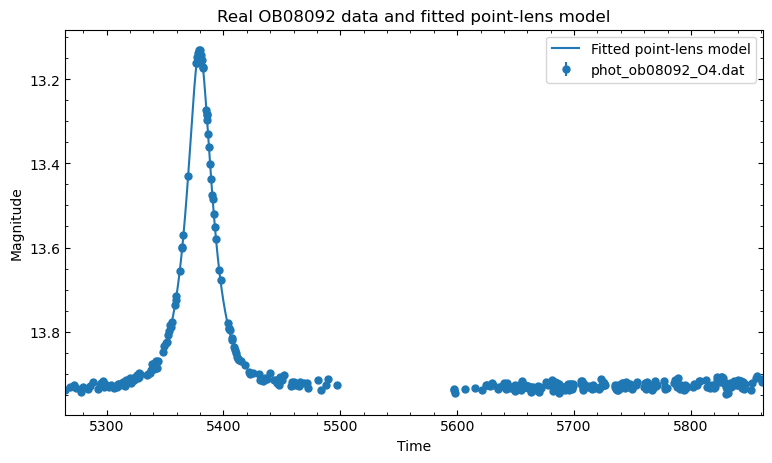

In [10]:
# fit_result.x contains the best-fitting parameter values found by the SciPy optimizer.
#
# The values are stored in the same order used earlier:
# [t_0, u_0, t_E]
#
# This line separates the three values into individual variables.

best_t_0, best_u_0, best_t_E = fit_result.x

# Update the Event object's microlensing model so that it uses the best-fitting t_0 value.
# t_0 is the time of closest alignment between the lens and the source star.
ob08092_event.model.parameters.t_0 = best_t_0

# Update the model with the best-fitting u_0 value.
# u_0 is the minimum lens-source separation in units of the Einstein radius.
ob08092_event.model.parameters.u_0 = best_u_0

# Update the model with the best-fitting t_E value.
# t_E is the Einstein crossing time and controls the
# approximate duration of the microlensing event.
ob08092_event.model.parameters.t_E = best_t_E

# Print a heading before displaying the fitted parameters.
print("Best-fitting parameters:")

# Display the parameter values now stored in the model.
print(ob08092_event.model.parameters)

# Create a new figure that is 9 inches wide and 5 inches tall.
plt.figure(figsize=(9, 5))

# Plot the real telescope observations.
ob08092_event.plot_data()


# Calculate and plot the theoretical point-lens light curve
# using the best-fitting parameters.
# The label appears in the graph legend.
ob08092_event.plot_model(label="Fitted point-lens model")

# Label the horizontal axis.
plt.xlabel("Time")

# Label the vertical axis.
plt.ylabel("Magnitude")

# Add a descriptive title to the graph.
plt.title("Real OB08092 data and fitted point-lens model")

# Display the legend identifying the fitted model.
plt.legend()

# Display the completed graph.
plt.show()



Plot the residuals:

\[
\text{residual} = \text{observed brightness} - \text{model brightness}.
\]

A good model should leave residuals scattered around zero without a clear pattern.


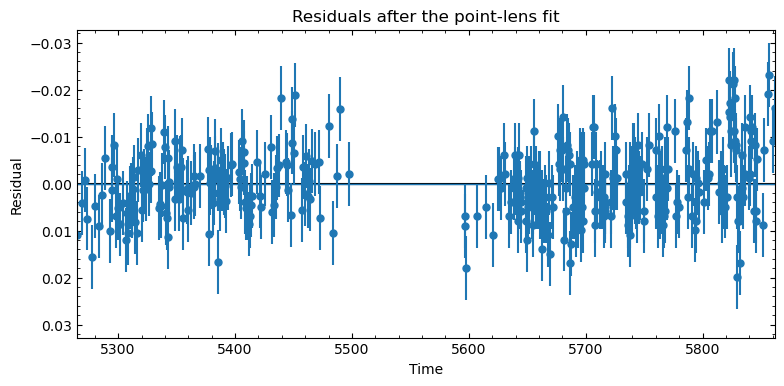

In [10]:
# Create a new figure that is 9 inches wide and 4 inches tall.

plt.figure(figsize=(9, 4))

# Calculate and plot the residuals for every observation.
# A residual measures the difference between:
# observed brightness - model-predicted brightness
# Residuals near zero mean the model closely matches the data.
ob08092_event.plot_residuals()

# Draw a horizontal reference line at residual = 0.
# Points above or below this line show where the observations differ from the model prediction.
# linewidth=1 controls the thickness of the line.
plt.axhline(0.0, linewidth=1)

# Label the horizontal axis.
plt.xlabel("Time")

# Label the vertical axis.
plt.ylabel("Residual")

# Add a title describing the graph.
plt.title("Residuals after the point-lens fit")

# Display the finished residual plot.
plt.show()



## What MulensModel did in Example 2

- Calculated a microlensing curve for every trial set of parameters.
- Fit the source and blend fluxes.
- Compared the prediction with the real observations.
- Returned chi-squared.
- Produced model and residual plots.

SciPy—not MulensModel—decided which trial parameters to test next.



# Example 3 — Compare a one-lens model with a star-plus-planet model

## Real event

This example uses **OGLE-2003-BLG-235/MOA-2003-BLG-53**.

The official MulensModel tutorial states that:

- this was the first microlensing planet discovery;
- the example data were downloaded from the NASA Exoplanet Archive;
- the package contains measurements from both OGLE and MOA.

The important question is:

> Does a single foreground lens explain the observations, or do we need a binary lens consisting of a host star and planet?


In [11]:
# Build the path to the folder containing the observational files
# for the microlensing event OGLE-2003-BLG-235 /
# MOA-2003-BLG-53.
# os.path.join() combines the folder names into one valid path.

ob03235_path = os.path.join(
    mm.DATA_PATH,
    "photometry_files",
    "OB03235",
)

# ------------------------------------------------------------
# Load the OGLE observations
# ------------------------------------------------------------

# Read the OGLE telescope data into a MulensData object.
ogle_data = mm.MulensData(
    
    # Build the complete path to the OGLE data file.
    file_name=os.path.join(ob03235_path, "OB03235_OGLE.tbl.txt"),

    # Tell MulensModel to ignore lines beginning with
    # either "\" or "|".
    #
    # These lines contain table formatting or metadata
    # rather than actual numerical observations.
    comments=["\\", "|"],

    # Give this dataset the label "OGLE" when it is plotted.
    plot_properties={"label": "OGLE"},
)

# ------------------------------------------------------------
# Load the MOA observations
# ------------------------------------------------------------

# Read the MOA telescope data into another MulensData object.
moa_data = mm.MulensData(

    # Build the complete path to the MOA data file.
    file_name=os.path.join(ob03235_path, "OB03235_MOA.tbl.txt"),

    # Ignore lines beginning with "\" or "|" because they
    # contain formatting or metadata rather than observations.
    comments=["\\", "|"],

    # Tell MulensModel that the MOA file stores brightness
    # measurements in flux units instead of magnitudes.
    # MulensModel can internally convert between flux and magnitude representations when needed.
    phot_fmt="flux",

    # Give this dataset the label "MOA" when it is plotted.
    plot_properties={"label": "MOA"},
)

# Count and print the number of OGLE observations.
# ogle_data.time contains one time value for each observation,
# so len(ogle_data.time) gives the total number of measurements.
print("OGLE observations:", len(ogle_data.time))

# Count and print the number of MOA observations.
print("MOA observations:", len(moa_data.time))


OGLE observations: 285
MOA observations: 1250



First define a **point-source, point-lens** model.

This assumes the foreground lens is a single object.


In [12]:
# Create a point-source, point-lens model

# Define a simple microlensing model containing one source star and one foreground lens.
# PSPL stands for: Point-Source, Point-Lens
planet_event_pspl_model = mm.Model({

    # t_0 is the time when the lens passes closest to the background source star.
    # This value is written as a Julian Date.
    "t_0": 2452848.06,

    # u_0 is the minimum projected separation between
    # the lens and source, measured in Einstein-radius units.
    # Smaller u_0 values generally produce higher magnification.
    "u_0": 0.133,

    # t_E is the Einstein crossing time in days.
    # It controls the characteristic duration of the event.
    "t_E": 61.5,
})

# ------------------------------------------------------------
# Connect the model to the real OGLE and MOA observations
# ------------------------------------------------------------

# Create an Event object that combines:
# 1. The OGLE observations
# 2. The MOA observations
# 3. The theoretical point-lens model
# Both datasets describe the same microlensing event,
# even though they were collected by different surveys.
planet_event_pspl = mm.Event(
    datasets=[ogle_data, moa_data],
    model=planet_event_pspl_model,
)

# ------------------------------------------------------------
# Calculate the model's chi-squared
# ------------------------------------------------------------

# Compare the point-lens model with all observations from both OGLE and MOA.
# get_chi2() calculates how strongly the real measurements
# disagree with the model predictions, while accounting for each measurement's uncertainty.
#
# np.asarray() converts the returned value into a NumPy array.
#
# .squeeze() removes any unnecessary dimensions.
#
# float() converts the result into one ordinary Python number.

pspl_chi2 = float(np.asarray(planet_event_pspl.get_chi2()).squeeze())

# Print the total chi-squared for the point-lens model.
print("Point-lens chi-squared:", pspl_chi2)


Point-lens chi-squared: 2363.664349594179



Now define a **binary-lens** model.

The extra parameters are:

- `q`: companion-to-host mass ratio
- `s`: projected separation in Einstein-radius units
- `alpha`: source-trajectory angle
- `rho`: source-star angular radius divided by the Einstein radius

These are the parameters used in the official MulensModel tutorial.


In [13]:
# Create a binary-lens model: host star + planet

# A binary-lens model contains two foreground lensing masses.
# In this example, the two masses represent:
# 1. A host star
# 2. A planetary companion
# These parameter values come from the official MulensModel
# tutorial for OGLE-2003-BLG-235 / MOA-2003-BLG-53.
planet_event_binary_model = mm.Model({

    # t_0 is the time when the source passes closest to the reference point of the lens system.
    # The time is written as a Julian Date.
    "t_0": 2452848.06,

    # u_0 is the minimum projected source-lens separation,
    # measured in units of the angular Einstein radius.
    "u_0": 0.133,

    # t_E is the Einstein crossing time, measured in days.
    # It describes the characteristic duration of the event.
    "t_E": 61.5,

    # rho is the angular radius of the background source star divided by the angular Einstein radius.
    # Including rho allows MulensModel to account for the source
    # being a finite-sized star rather than an infinitely small point.
    "rho": 0.00096,

    # q is the mass ratio of the second lens to the first lens.
    # Here:
    # q = companion mass / host-star mass
    # A value of 0.0039 means the companion has about 0.39%
    # of the mass of the host lens.
    "q": 0.0039,

    # s is the projected separation between the two lensing masses,
    # measured in units of the angular Einstein radius.
    # s near 1 often produces strong planetary caustic effects.
    "s": 1.120,

    # alpha is the angle of the source star's trajectory relative
    # to the binary-lens axis, measured in degrees.
    #
    # The binary-lens axis is the line connecting the host star
    # and the planetary companion.
    "alpha": 43.8,
})

# ------------------------------------------------------------
# Choose the numerical magnification method
# ------------------------------------------------------------

# Binary-lens magnification is more mathematically complicated
# than point-lens magnification, especially when the source passes
# near or across a caustic.
#
# This tells MulensModel to use the VBBL method between
# Julian Dates 2452833.0 and 2452845.0.
planet_event_binary_model.set_magnification_methods([

    # Beginning of the interval where VBBL should be used.
    2452833.0,

    # VBBL is a numerical binary-lens magnification method
    # that can accurately include finite-source effects.
    "VBBL",

    # End of the interval where VBBL should be used.
    2452845.0,
])

# Outside this time interval, MulensModel uses its default
# magnification method. Using the more computationally expensive
# VBBL calculation only near the anomaly makes the calculation faster.


# ------------------------------------------------------------
# Connect the binary-lens model to the observations
# ------------------------------------------------------------

# Create an Event object that combines:
# 1. The OGLE observations
# 2. The MOA observations
# 3. The star-plus-planet binary-lens model

planet_event_binary = mm.Event(
    datasets=[ogle_data, moa_data],
    model=planet_event_binary_model,
)


# ------------------------------------------------------------
# Calculate chi-squared for the binary-lens model
# ------------------------------------------------------------

# Compare the binary-lens prediction with all of the OGLE and MOA observations.
# get_chi2() measures the disagreement between the model
# and the data while accounting for measurement uncertainties.

binary_chi2 = float(np.asarray(planet_event_binary.get_chi2()).squeeze())

# ------------------------------------------------------------
# Compare the point-lens and binary-lens models
# ------------------------------------------------------------

# Print the chi-squared value from the simpler one-lens model.
print("Point-lens chi-squared:", pspl_chi2)

# Print the chi-squared value from the star-plus-planet model.
print("Binary-lens chi-squared:", binary_chi2)

# Calculate the improvement in chi-squared:
# delta chi-squared = point-lens chi-squared - binary-lens chi-squared
#
# A large positive value means that the binary-lens model
# agrees with the observations better than the point-lens model.
print("Improvement, delta chi-squared:", pspl_chi2 - binary_chi2)


Point-lens chi-squared: 2363.664349594179
Binary-lens chi-squared: 1774.4164856168165
Improvement, delta chi-squared: 589.2478639773624



A large positive value of

\[
\Delta\chi^2=\chi^2_{\rm point\ lens}-\chi^2_{\rm binary\ lens}
\]

means the binary-lens model matches the data better.

Now plot the two predictions against the same observations.


/opt/anaconda3/lib/python3.13/site-packages/MulensModel/utils.py:148: UserWarning: Flux to magnitude conversion approached negative flux
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/MulensModel/utils.py:151: RuntimeWarning: invalid value encountered in log10
  mag = zeropoint - 2.5 * np.log10(flux)
/opt/anaconda3/lib/python3.13/site-packages/MulensModel/mulensdata.py:512: UserWarning: Some good data points have scaled errorbars with negative values. Setting them to zero for plotting.
Dataset: MOA
Epochs: [2451724.984743 2451735.999816 2451816.931292 2451817.868943
 2452068.114436 2452176.880222 2452185.913052 2452420.970783
 2452438.97773  2452533.873316 2452547.926567 2452551.909314
 2452551.924018 2452754.082603 2452759.235935]
  warnings.warn(msg.format(kind, self._get_name(), self.time[indexes]))


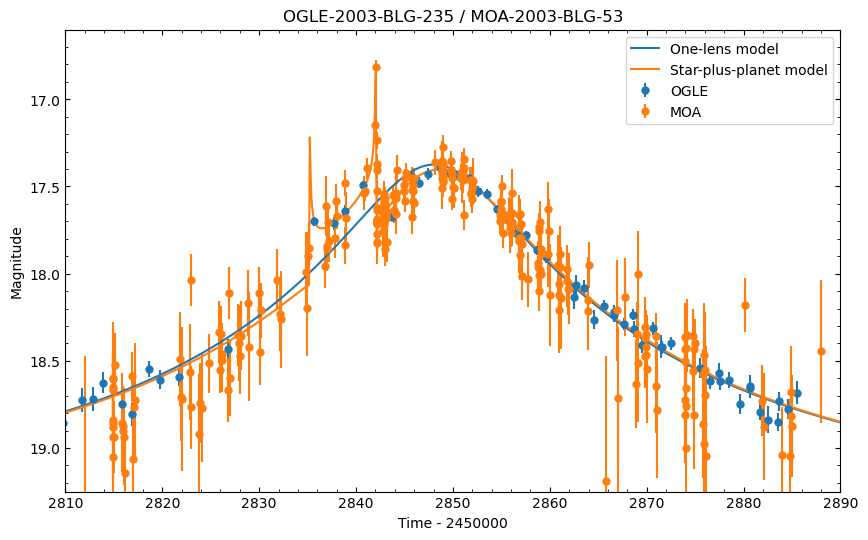

In [14]:
# Create a new figure that is 10 inches wide and 6 inches tall.
plt.figure(figsize=(10, 6))

# Plot the real OGLE and MOA telescope observations.
#
# planet_event_binary contains the same two observational datasets used for both model comparisons.
# subtract_2450000=True shortens the displayed Julian Dates.
# For example:
# 2452848.06 becomes 2848.06
planet_event_binary.plot_data(subtract_2450000=True)

# Plot the theoretical point-source, point-lens model.
# This model assumes that the foreground lens is one object with no planetary companion.
planet_event_pspl.plot_model(
   
    # Calculate and draw the model between these two full Julian Dates.
    t_range=[2452810, 2452890],
   
    # Subtract 2,450,000 from the times displayed on the horizontal axis.
    subtract_2450000=True,
   
    # Give this curve a name for the graph legend.
    label="One-lens model",
)

# Plot the theoretical binary-lens model over the same range of observing times.
# This model represents a host star with a planetary companion.
planet_event_binary.plot_model(

    # Use the same time range as the point-lens model
    # so that the two predictions can be compared directly.
    t_range=[2452810, 2452890],

    # Display shortened Julian Dates on the x-axis.
    subtract_2450000=True,

    # Give this curve a name for the graph legend.
    label="Star-plus-planet model",
)
# Limit the horizontal axis to the displayed times 2810 through 2890.
# Because 2,450,000 was subtracted, these correspond to full Julian Dates 2452810 through 2452890.
plt.xlim(2810, 2890)

# Set the vertical-axis range.
# The larger magnitude value is listed first, which reverses the y-axis:
# 19.25 appears near the bottom
# 16.6 appears near the top
#
# This follows the astronomical convention that smaller
# magnitudes represent brighter objects.
plt.ylim(19.25, 16.6)

# Label the horizontal axis and explain that 2,450,000 has been subtracted from each Julian Date.
plt.xlabel("Time - 2450000")

# Label the vertical axis.
plt.ylabel("Magnitude")

# Add the name of the real microlensing event as the title.
plt.title("OGLE-2003-BLG-235 / MOA-2003-BLG-53")

# Display a legend identifying the one-lens and star-plus-planet model curves.
plt.legend()

# Display the finished graph.
plt.show()


#In summary, this cell overlays 3 things:
#Real OGLE and MOA observations
              #+
#Theoretical one-lens model
              #+
#Theoretical star-plus-planet model


Zoom in on the region where the planetary deviation is strongest.


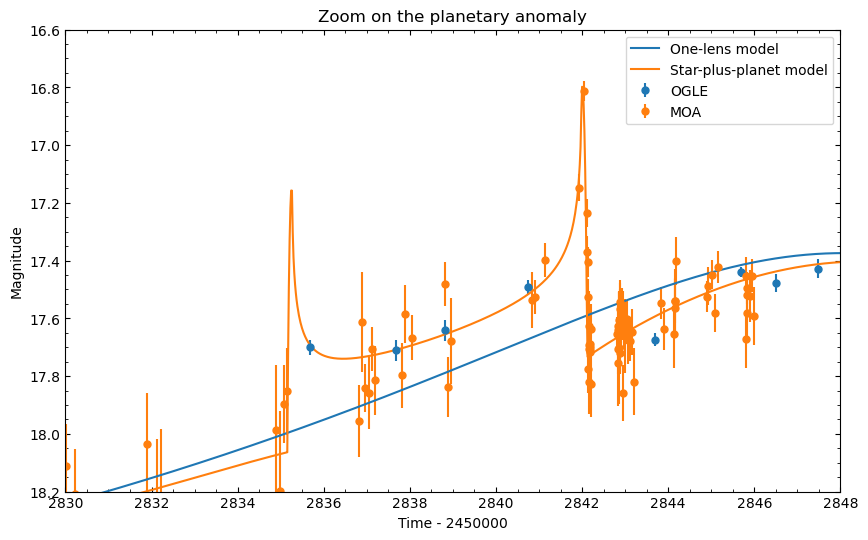

In [15]:
# Create a new figure that is 10 inches wide and 6 inches tall.

plt.figure(figsize=(10, 6))

# Plot the real OGLE and MOA observations.
# subtract_2450000=True shortens the Julian Dates shown on the horizontal axis.
# For example:
# 2452835 becomes 2835.
planet_event_binary.plot_data(subtract_2450000=True)

# Plot the simple one-lens model over the time range surrounding the suspected planetary anomaly.
planet_event_pspl.plot_model(

    # Calculate the model only between these two full Julian Dates.
    t_range=[2452830, 2452848],

    # Display shortened Julian Dates on the x-axis.
    subtract_2450000=True,

    # Give this curve a label for the legend.
    label="One-lens model",
)

# Plot the star-plus-planet binary-lens model over the same time range.
planet_event_binary.plot_model(

    # Use the same time interval so the two models can be compared directly.
    t_range=[2452830, 2452848],

    # Display shortened Julian Dates on the x-axis.
    subtract_2450000=True,

    # Give this curve a label for the legend.
    label="Star-plus-planet model",
)

# Zoom the horizontal axis to the interval from 2830 to 2848.
# These displayed values correspond to full Julian Dates 2452830 through 2452848.
plt.xlim(2830, 2848)

# Set the vertical-axis limits.
# The larger magnitude value is listed first, so the axis is inverted:
# 18.2 appears lower on the graph
# 16.6 appears higher on the graph
# This follows the astronomical convention that smaller magnitudes mean brighter objects.
plt.ylim(18.2, 16.6)


# Label the horizontal axis and indicate that 2,450,000 has been subtracted from the Julian Dates.
plt.xlabel("Time - 2450000")

# Label the vertical axis.
plt.ylabel("Magnitude")

# Add a title explaining that this graph focuses on the planetary deviation.
plt.title("Zoom on the planetary anomaly")

# Display the legend identifying both model curves.
plt.legend()

# Show the completed graph.
plt.show()


#This is essentially a zoomed-in version of the previous plot 

#In summary:
#Full event plot
      #↓
#Find the region where the models disagree
      #↓
#Zoom into that region
      #↓
#Examine the planetary anomaly


## What MulensModel did in Example 3

- Loaded measurements in two different formats: magnitude and flux.
- Fit each telescope's source and blend flux.
- Calculated a single-lens model.
- Calculated a binary-lens model with finite-source effects.
- Calculated chi-squared for both hypotheses.
- Allowed us to see whether the planetary model explains deviations that the one-lens model misses.



# Example 4 — Multiple telescopes and finite-source effects

## Real event

This example uses observations of **MOA-2008-BLG-310** from several telescopes.

The official MulensModel example attributes the data and model to Janczak et al. (2010).

This was a very high-magnification event. Near perfect alignment, the background source star's finite angular size matters, so we cannot always treat it as an infinitely tiny point.

## Note

This section isolates the finite-source point-lens calculation to demonstrate multi-observatory data handling and finite-source effects. It does not reproduce the complete planetary binary-lens analysis of MOA-2008-BLG-310.


In [16]:
# ------------------------------------------------------------
# Find all telescope data files for MOA-2008-BLG-310
# ------------------------------------------------------------

# Build a list containing every file in the MB08310 folder whose filename ends in ".tbl".

mb08310_files = sorted(

    # glob.glob() searches for files that match a pattern.
    glob.glob(

        # Build the complete search pattern:
        # <data folder>/photometry_files/MB08310/*.tbl
        # The * is a wildcard, meaning:
        # "match any filename that ends in .tbl"
        os.path.join(
            mm.DATA_PATH,
            "photometry_files",
            "MB08310",
            "*.tbl",
        )
    )
)

# sorted() places the file paths in alphabetical order.
# This makes the dataset order consistent each time the notebook is run.


# ------------------------------------------------------------
# Create an empty list for the loaded datasets
# ------------------------------------------------------------

# Each telescope file will be converted into a MulensData object and added to this list.

mb08310_datasets = [] 

# ------------------------------------------------------------
# Load each telescope file
# ------------------------------------------------------------

# Go through the list of telescope file paths one at a time.

for file_name in mb08310_files:

    # Extract only the filename from the complete path.
    #
    # Example:
    # /path/to/data/Auck_0300089_PLC_001.tbl
    # becomes:
    # Auck_0300089_PLC_001.tbl
    # Then split the filename at the first underscore.
    # "Auck_0300089_PLC_001.tbl"
    # becomes:
    # ["Auck", "0300089_PLC_001.tbl"]
    # [0] selects the first part, giving the label "Auck".
    label = os.path.basename(file_name).split("_", maxsplit=1)[0]

    # Read the current telescope file into a MulensData object.
    dataset = mm.MulensData(

        # Use the current file path from the loop.
        file_name=file_name,

        # Ignore lines beginning with "\" or "|".
        # These lines contain table formatting or metadata, rather than numerical observations.
        comments=["\\", "|"],

        # Give the dataset a short telescope label that will appear in plots and legends.
        plot_properties={"label": label},
    )

    # Add the newly created MulensData object to the list of telescope datasets.
    mb08310_datasets.append(dataset)

# ------------------------------------------------------------
# Report how many datasets were loaded
# ------------------------------------------------------------

# len(mb08310_datasets) counts the number of MulensData objects stored in the list.

print("Number of telescope datasets:", len(mb08310_datasets))

# ------------------------------------------------------------
# Print information about each dataset
# ------------------------------------------------------------

# zip() pairs each original file path with its corresponding MulensData object.
# For example:
# first file path  ↔ first dataset
# second file path ↔ second dataset
for file_name, dataset in zip(mb08310_files, mb08310_datasets):

    # Print:
    # 1. The filename
    # 2. A separator
    # 3. The number of observations in that dataset
    # 4. The word "observations"
    print(
        os.path.basename(file_name),
        "-",
        len(dataset.time),
        "observations",
    )


Number of telescope datasets: 7
Auck_0300089_PLC_001.tbl - 76 observations
Bron_0300089_PLC_002.tbl - 149 observations
CTIO_H_0300089_PLC_004.tbl - 286 observations
CTIO_I_0300089_PLC_005.tbl - 46 observations
Canopus_0300089_PLC_003.tbl - 12 observations
Danish_0300089_PLC_006.tbl - 51 observations
MOA_0300089_PLC_007.tbl - 2862 observations



Define a point-lens model that includes `t_star`, the time required for the lens to cross one source-star radius.

We tell MulensModel to use a finite-source calculation close to the peak.


In [17]:
# ------------------------------------------------------------
# Define the finite-source model parameters
# ------------------------------------------------------------

# t_0 is the time of closest approach between the lens and the center of the background source star.
# The value is given as a full Julian Date.

mb08310_t_0 = 2454656.39975

# u_0 is the minimum projected separation between the lens
# and the center of the source star, measured in units of the angular Einstein radius.
# This very small value means the alignment is extremely close,
# so the event reaches a high magnification.
mb08310_u_0 = 0.00300

# t_E is the Einstein crossing time in days.
# It describes the characteristic duration of the microlensing event.
mb08310_t_E = 11.14

# t_star is the time required for the lens to move across
# one angular radius of the background source star.
# Including t_star tells MulensModel that the source has
# a measurable finite size rather than being an ideal point.
mb08310_t_star = 0.05487

# ------------------------------------------------------------
# Create the theoretical finite-source microlensing model
# ------------------------------------------------------------

# Build a point-lens model that includes finite-source effects.
#
# The foreground lens is still treated as one object,
# but the background source is treated as a disk with a nonzero angular size.

finite_source_model = mm.Model({

    # Time of closest approach.
    "t_0": mb08310_t_0,

    # Minimum lens-source separation.
    "u_0": mb08310_u_0,

    # Einstein crossing time.
    "t_E": mb08310_t_E,

    # Source-radius crossing time.
    "t_star": mb08310_t_star,
})

# ------------------------------------------------------------
# Select the finite-source magnification algorithm
# ------------------------------------------------------------

# Store the name of the numerical method that MulensModel will use near the peak of the event.
# This method assumes a uniformly bright circular source
# and uses the Gould (1994) finite-source approximation.

finite_source_method = "finite_source_uniform_Gould94"

# Tell MulensModel when to use the finite-source method.
finite_source_model.set_magnification_methods([

    
    # Begin using the finite-source method two source-crossing
    # times before the time of closest approach.
    mb08310_t_0 - 2.0 * mb08310_t_star,

    # Use the selected finite-source calculation.
    finite_source_method,

    # Stop using the finite-source method two source-crossing times after the time of closest approach.
    mb08310_t_0 + 2.0 * mb08310_t_star,
])

# Outside this narrow time interval, MulensModel uses its default point-source magnification method.
# This is more efficient because the finite-source calculation
# is most important only very close to the event peak.


# ------------------------------------------------------------
# Connect the model to all telescope datasets
# ------------------------------------------------------------

# Create one Event object containing:
# 1. All seven telescope datasets loaded earlier
# 2. The finite-source theoretical model
# MulensModel can then compare the same physical model against observations from all telescopes.
mb08310_event = mm.Event(
    datasets=mb08310_datasets,
    model=finite_source_model,
)

# ------------------------------------------------------------
# Select the reference dataset
# ------------------------------------------------------------

# Check that the list contains at least seven datasets.
# Python uses zero-based indexing:
# index 0 = first dataset
# index 1 = second dataset
# ...
# index 6 = seventh dataset
if len(mb08310_datasets) > 6:

    # Use the seventh dataset as the reference photometric scale.
    # The other telescope datasets are placed on a brightness
    # scale that can be compared with this reference dataset.
    mb08310_event.data_ref = 6

# ------------------------------------------------------------
# Inspect the model and calculate chi-squared
# ------------------------------------------------------------

# Print the parameters currently stored in the finite-source model.

print(finite_source_model.parameters)

# Calculate and print the total chi-squared for the model compared with all telescope observations.
print(
    "Chi-squared:",

    
    # get_chi2() compares the predicted brightness with
    # every observation while accounting for uncertainty.
    #
    # np.asarray() converts the returned result to a NumPy array.
    #
    # .squeeze() removes unnecessary array dimensions.
    #
    # float() converts the result into one ordinary Python number.
    float(np.asarray(mb08310_event.get_chi2()).squeeze()),
)


    t_0 (HJD)       u_0    t_E (d)    t_star (d) 
2454656.39975  0.003000    11.1400      0.054870 
Chi-squared: 7777.593988123474



Plot all telescope measurements and the same physical model.


/opt/anaconda3/lib/python3.13/site-packages/MulensModel/mulensdata.py:512: UserWarning: Some good data points have scaled errorbars with negative values. Setting them to zero for plotting.
Dataset: CTIO
Epochs: [2454672.5931  2454672.60009 2454672.64212]
  warnings.warn(msg.format(kind, self._get_name(), self.time[indexes]))


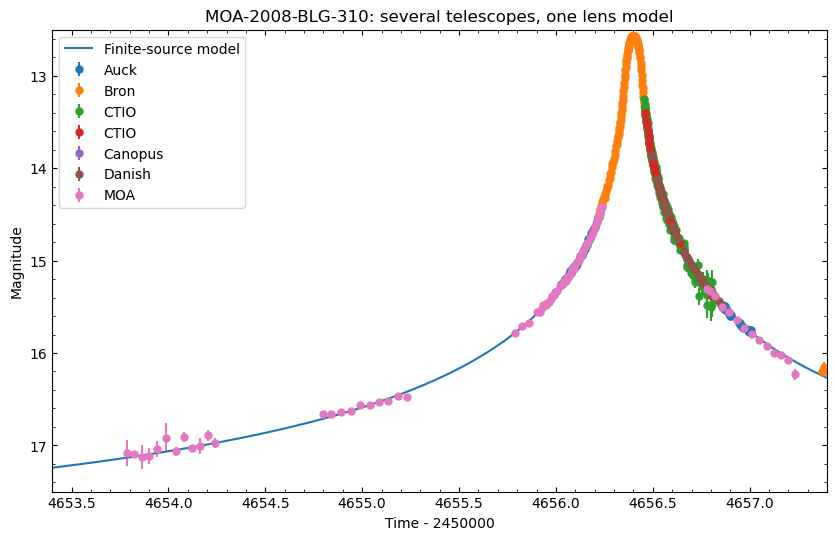

In [18]:
# Create a new figure that is 10 inches wide and 6 inches tall.

plt.figure(figsize=(10, 6))

# Plot the observations from all telescope datasets connected to mb08310_event.
# subtract_2450000=True shortens the Julian Dates shown on the horizontal axis.
# For example:
# 2454656.4 becomes 4656.4.
mb08310_event.plot_data(subtract_2450000=True)

# Plot the theoretical finite-source microlensing model.
mb08310_event.plot_model(

    # Display shortened Julian Dates on the horizontal axis.
    subtract_2450000=True,

    # Begin calculating and plotting the model at full Julian Date 2454653.4.
    t_start=2454653.4,

    # Stop calculating and plotting the model at full Julian Date 2454657.4.
    t_stop=2454657.4,

    # Give the model curve a label for the legend.
    label="Finite-source model",
)

# Limit the displayed horizontal range.
# Because 2,450,000 has been subtracted, these values
# correspond to full Julian Dates 2454653.4 to 2454657.4.
plt.xlim(4653.4, 4657.4)

# Set the displayed magnitude range.
# The larger magnitude value is listed first, so the vertical axis is inverted.
# This follows the astronomical convention:
# smaller magnitude = brighter object.
plt.ylim(17.5, 12.5)

# Label the horizontal axis and show that 2,450,000 was subtracted from the Julian Dates.
plt.xlabel("Time - 2450000")

# Label the vertical axis.
plt.ylabel("Magnitude")

# Add a title explaining that several telescope datasets
# are being compared with one physical lens model.
plt.title("MOA-2008-BLG-310: several telescopes, one lens model")

# Display the legend containing the model label and telescope labels.
plt.legend()

# Display the completed graph.
plt.show()



Plot residuals from every telescope.


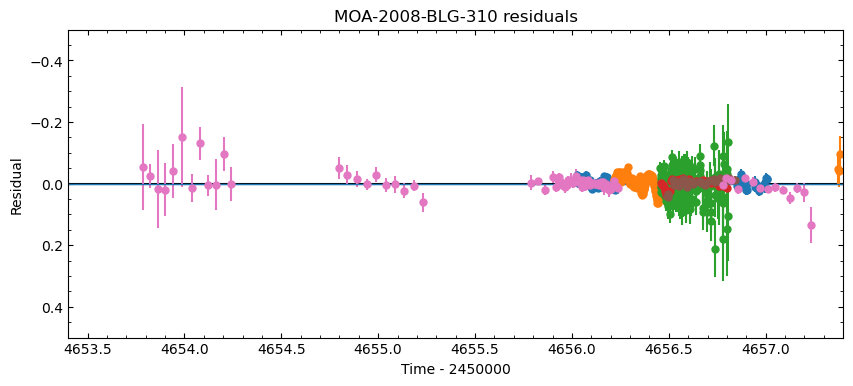

In [19]:
# Create a new figure that is 10 inches wide and 4 inches tall.

plt.figure(figsize=(10, 4))

# Calculate and plot the residuals for every telescope dataset.
# A residual is the difference between the observed brightness
# and the brightness predicted by the model.
# subtract_2450000=True shortens the Julian Dates displayed on the horizontal axis.
mb08310_event.plot_residuals(subtract_2450000=True)

# Draw a horizontal reference line at residual = 0.
# Points near this line agree closely with the model.
# Points far from this line disagree more strongly.
plt.axhline(0.0, linewidth=1)

# Limit the horizontal axis to the time range surrounding the microlensing event.
plt.xlim(4653.4, 4657.4)

# Label the horizontal axis.
plt.xlabel("Time - 2450000")

# Label the vertical axis.
plt.ylabel("Residual")

# Add a title to the residual plot.
plt.title("MOA-2008-BLG-310 residuals")

# Display the completed graph.
plt.show()



Plot the lens-source trajectory.

This is not a normal brightness graph. It shows the geometry in the lens plane.


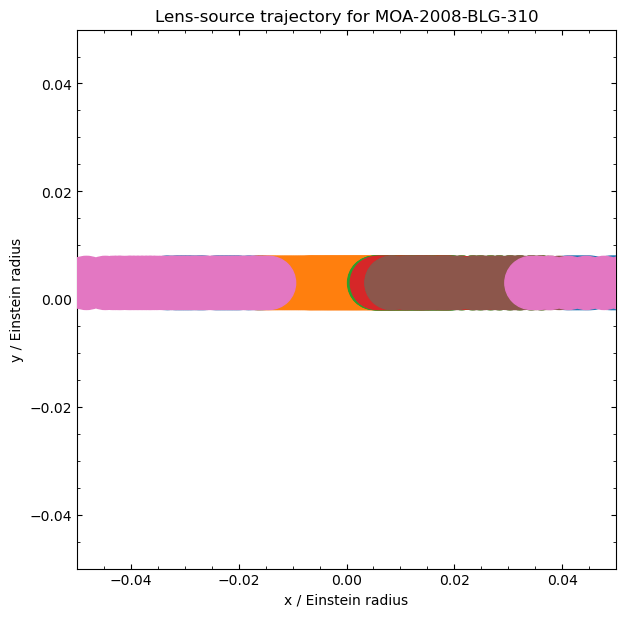

In [20]:
# Create a square figure that is 7 inches wide and 7 inches tall.

plt.figure(figsize=(7, 7))

# Plot the path followed by the source star relative to the foreground lens.
# This is a geometry plot, not a brightness-versus-time plot.
mb08310_event.plot_trajectory()

# Draw the source star at the positions corresponding
# to the observation times in the telescope datasets.
# Because this is a finite-source model, the source can be
# represented with a nonzero size rather than as a single point.
mb08310_event.plot_source_for_datasets()

# Make one unit on the x-axis the same visual length as one unit on the y-axis.
# Without this, circles and trajectories could appear distorted.
plt.gca().set_aspect("equal")

# Set the displayed horizontal range in units of the angular Einstein radius.
plt.xlim(-0.05, 0.05)

# Set the displayed vertical range in units of the angular Einstein radius.
plt.ylim(-0.05, 0.05)

# Label the horizontal coordinate.
# The position is normalized by the angular Einstein radius.
plt.xlabel("x / Einstein radius")

# Label the vertical coordinate.
plt.ylabel("y / Einstein radius")

# Add a title describing the geometry being shown.
plt.title("Lens-source trajectory for MOA-2008-BLG-310")

# Display the completed trajectory plot.
plt.show()



## What MulensModel did in Example 4

- Read several observatories' data files.
- Treated them as measurements of the same physical event.
- Fit separate source and blend fluxes for each dataset.
- Switched to a finite-source magnification algorithm near the peak.
- Calculated residuals.
- Drew the physical lens-source trajectory.



# Example 5 — Annual microlensing parallax

## Real event

This example uses **OGLE-2005-BLG-086**, also listed as event 3291 in Wyrzykowski et al. (2015).

For a long event, Earth moves significantly around the Sun while the event is happening. The observer's acceleration can distort the otherwise symmetric microlensing curve.

The official MulensModel parallax tutorial compares:

1. A model with straight-line relative motion and no parallax.
2. A parallax model with positive `u_0`.
3. A second, nearly degenerate parallax model with negative `u_0`.


In [21]:
# ------------------------------------------------------------
# Build the path to the OGLE-2005-BLG-086 data file
# ------------------------------------------------------------

# os.path.join() combines the main MulensModel data folder
# with the subfolders and filename needed for this example.

ob05086_file = os.path.join(
    mm.DATA_PATH,
    "photometry_files",
    "OB05086",
    "starBLG234.6.I.218982.dat",
)

# ------------------------------------------------------------
# Load the observational data
# ------------------------------------------------------------

# Read the telescope measurements into a MulensData object.

ob05086_data = mm.MulensData(

    # Tell MulensModel which observational file to load.
    file_name=ob05086_file,

    # The times in this file have 2,450,000 removed from them.
    # add_2450000=True adds that value back so MulensModel stores complete Julian Dates.
    # Full dates are especially important for parallax calculations
    # because MulensModel needs to know Earth's actual position in its orbit at each observation time.
    add_2450000=True,

    # Give the dataset a label that will appear in plots and legends.
    plot_properties={"label": "OGLE data"},
)

# ------------------------------------------------------------
# Store the event's sky coordinates
# ------------------------------------------------------------

# Save the position of the event on the sky.
# The first part is right ascension:
#   18 hours, 04 minutes, 45.71 seconds
# The second part is declination:
#   -26 degrees, 59 arcminutes, 15.2 arcseconds
# MulensModel needs the sky coordinates to calculate how
# Earth's orbital motion affects the apparent lens-source trajectory.

ob05086_coords = "18:04:45.71 -26:59:15.2"

# ------------------------------------------------------------
# Inspect the loaded data
# ------------------------------------------------------------

# Count the total number of observations in the dataset.
# ob05086_data.time contains one time value for every telescope measurement.
print("Number of observations:", len(ob05086_data.time))

# Print the first observation time.
# [0] selects the first value in the time array.
# Because add_2450000=True was used, this should be
# a full Julian Date beginning with approximately 245....
print("First full Julian Date:", ob05086_data.time[0])


Number of observations: 640
First full Julian Date: 2452127.52182



`add_2450000=True` is important here because MulensModel needs the real observing dates to calculate Earth's position.

Create the three models using the parameters provided in the official parallax tutorial.


In [22]:
# ------------------------------------------------------------
# Create a point-lens model without annual parallax
# ------------------------------------------------------------

# This model assumes that the relative motion between the lens
# and the source follows a straight line at constant speed.
# It does not include the effect of Earth moving around the Sun.

no_parallax_model = mm.Model({

    # t_0 is the time of closest approach between the lens and the background source star.
    # The time is given as a full Julian Date.
    "t_0": 2453628.29062,

    # u_0 is the minimum projected lens-source separation,
    # measured in units of the angular Einstein radius.
    "u_0": 0.37263,

    # t_E is the Einstein crossing time in days.
    # It describes the characteristic duration of the event.
    "t_E": 102.387105,
})

# ------------------------------------------------------------
# Create an annual-parallax model with positive u_0
# ------------------------------------------------------------

# This model includes the effect of Earth's orbital motion.
# Because Earth accelerates around the Sun, the observer does not
# follow a perfectly straight path during a long microlensing event.
# This can create a small asymmetry or distortion in the light curve.

positive_u0_parallax_model = mm.Model(
    {

        # Time of closest approach.
        "t_0": 2453630.35507,

        # Positive u_0 means that the source passes on one
        # chosen side of the lens in the model's coordinate system.
        # The sign describes trajectory orientation, not distance.
        "u_0": 0.488817,

        # Einstein crossing time in days.
        "t_E": 93.611301,

        # North component of the microlensing parallax vector.
        # Together, pi_E_N and pi_E_E describe the size
        # and direction of the parallax effect on the sky.
        "pi_E_N": 0.2719,

        # East component of the microlensing parallax vector.
        "pi_E_E": 0.1025,

        # Reference time used when defining the parallax calculation.
        # MulensModel evaluates Earth's motion relative to this epoch.
        "t_0_par": 2453628.0,
    },

    # Supply the event's sky coordinates.
    # MulensModel needs the sky position to calculate Earth's
    # projected motion relative to this particular line of sight.
    coords=ob05086_coords,
)

# ------------------------------------------------------------
# Create a second annual-parallax model with negative u_0
# ------------------------------------------------------------

# Microlensing events can sometimes have two similar parallax
# solutions: one with positive u_0 and one with negative u_0.
# These models represent source trajectories passing on opposite
# sides of the lens in the chosen coordinate system.

negative_u0_parallax_model = mm.Model(
    {
        # Time of closest approach for this solution.
        "t_0": 2453630.67778,

        # Negative u_0 represents the opposite trajectory orientation from the positive-u_0 model.
        # Its absolute value still describes the minimum separation.
        "u_0": -0.415677,

        # Einstein crossing time in days.
        "t_E": 110.120755,

        # North component of the parallax vector.
        # Its sign and value differ from the positive-u_0 solution
        # because the fitted trajectory orientation is different.
        "pi_E_N": -0.2972,

        # East component of the parallax vector.
        "pi_E_E": 0.1103,

        # Use the same parallax reference time as the other model.
        "t_0_par": 2453628.0,
    },
    coords=ob05086_coords,
)

# ------------------------------------------------------------
# Connect each model to the real OGLE observations
# ------------------------------------------------------------

# Create an Event object for the model without parallax.

no_parallax_event = mm.Event(
    datasets=[ob05086_data],
    model=no_parallax_model,
)

# Create an Event object for the positive-u_0 parallax model.
positive_parallax_event = mm.Event(
    datasets=[ob05086_data],
    model=positive_u0_parallax_model,
)

# Create an Event object for the negative-u_0 parallax model.
negative_parallax_event = mm.Event(
    datasets=[ob05086_data],
    model=negative_u0_parallax_model,
)

# ------------------------------------------------------------
# Calculate chi-squared for all three models
# ------------------------------------------------------------

# Calculate how well the no-parallax model matches the data.

chi2_no_parallax = float(
    np.asarray(no_parallax_event.get_chi2()).squeeze()
)

# Calculate chi-squared for the positive-u_0 parallax model.
chi2_positive = float(
    np.asarray(positive_parallax_event.get_chi2()).squeeze()
)

# Calculate chi-squared for the negative-u_0 parallax model.
chi2_negative = float(
    np.asarray(negative_parallax_event.get_chi2()).squeeze()
)

# ------------------------------------------------------------
# Print and compare the results
# ------------------------------------------------------------

# Print the chi-squared for the model that ignores Earth's motion.

print("No-parallax chi-squared:", chi2_no_parallax)

# Print the chi-squared for the positive-u_0 parallax solution.
print("Positive-u0 parallax chi-squared:", chi2_positive)

# Print the chi-squared for the negative-u_0 parallax solution.
print("Negative-u0 parallax chi-squared:", chi2_negative)

# Find the smaller chi-squared of the two parallax models, then compare it with the no-parallax model.
# min(chi2_positive, chi2_negative) selects the better of the two parallax solutions.
# A large positive result means that including annual parallax improves the match to the observations.
print(
    "Improvement over no parallax:",
    chi2_no_parallax - min(chi2_positive, chi2_negative),
)


No-parallax chi-squared: 1359.4341492772812
Positive-u0 parallax chi-squared: 946.7373988619632
Negative-u0 parallax chi-squared: 944.3739427306213
Improvement over no parallax: 415.06020654665997



Plot the real observations and all three physical models.


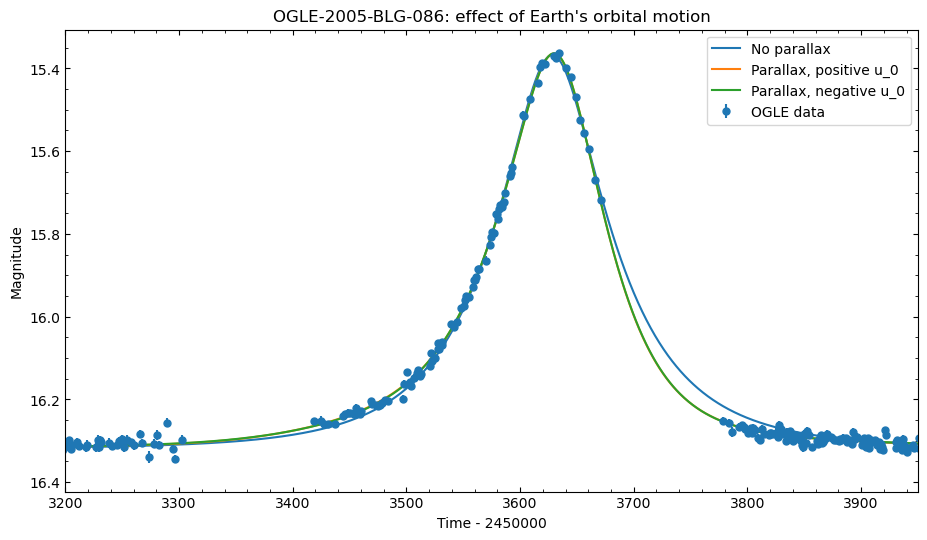

In [23]:
# ------------------------------------------------------------
# Store plotting settings that will be reused
# ------------------------------------------------------------

# Create a dictionary containing plotting options that all three model curves will share.
#
# Storing these settings once avoids repeating the same arguments in every plot_model() call.

plot_options = {

    # Subtract 2,450,000 from the Julian Dates shown on the x-axis.
    # For example:
    # 2453630 becomes 3630.
    "subtract_2450000": True,

    # Begin calculating each model at full Julian Date 2453200.
    "t_start": 2453200.0,

    # Stop calculating each model at full Julian Date 2453950.
    "t_stop": 2453950.0,
}

# ------------------------------------------------------------
# Create the figure and plot the real observations
# ------------------------------------------------------------

# Create a figure that is 11 inches wide and 6 inches tall.

plt.figure(figsize=(11, 6))

# Plot the real OGLE observations.
# All three Event objects use the same ob05086_data dataset,
# so the data could be plotted from any one of them.
# subtract_2450000=True shortens the displayed Julian Dates.
negative_parallax_event.plot_data(subtract_2450000=True)

# ------------------------------------------------------------
# Plot the model without parallax
# ------------------------------------------------------------

# Plot the theoretical point-lens model that ignores Earth's orbital motion.

no_parallax_event.plot_model(

    # Give this model curve a label for the legend.
    label="No parallax",

    # **plot_options passes every key-value pair from the plot_options dictionary into plot_model().
    # This is equivalent to writing:
    # subtract_2450000=True,
    # t_start=2453200.0,
    # t_stop=2453950.0
    **plot_options,
)

# ------------------------------------------------------------
# Plot the positive-u_0 parallax solution
# ------------------------------------------------------------

# Plot the annual-parallax model in which u_0 is positive.

positive_parallax_event.plot_model(

    # Give the curve a descriptive legend label.
    label="Parallax, positive u_0",

    # Reuse the same time range and time-axis settings.
    **plot_options,
)

# ------------------------------------------------------------
# Plot the negative-u_0 parallax solution
# ------------------------------------------------------------

# Plot the second annual-parallax model, in which u_0 is negative.

negative_parallax_event.plot_model(

    # Give this curve a separate legend label.
    label="Parallax, negative u_0",

    # Reuse the shared plotting settings.
    **plot_options,
)

# ------------------------------------------------------------
# Format and display the graph
# ------------------------------------------------------------

# Limit the displayed horizontal axis to shortened Julian Dates 3200 through 3950.
# These correspond to full Julian Dates 2453200 through 2453950.

plt.xlim(3200, 3950)

# Label the horizontal axis and show that 2,450,000 has been subtracted from the Julian Dates.
plt.xlabel("Time - 2450000")

# Label the vertical axis.
plt.ylabel("Magnitude")

# Add a title explaining that the graph compares models with and without Earth's orbital motion.
plt.title("OGLE-2005-BLG-086: effect of Earth's orbital motion")

# Display a legend identifying the three model curves.
plt.legend()

# Display the completed graph.
plt.show()



Zoom near the region where the no-parallax model disagrees most clearly.


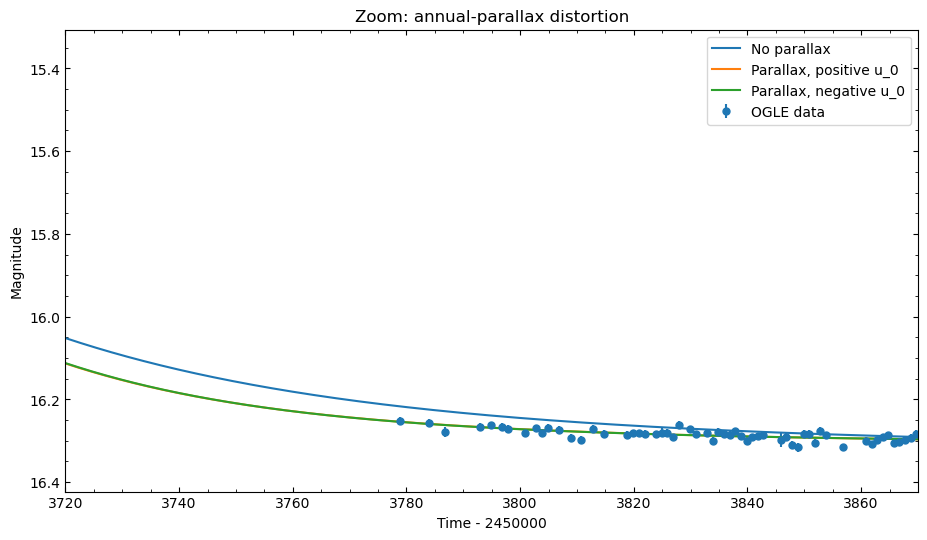

In [24]:
# Create a new figure that is 11 inches wide and 6 inches tall.

plt.figure(figsize=(11, 6))

# Plot the real OGLE observations.
# All three Event objects contain the same observational dataset,
# so the data could be plotted from any one of them.
# subtract_2450000=True shortens the Julian Dates shown on the horizontal axis.
negative_parallax_event.plot_data(subtract_2450000=True)

# ------------------------------------------------------------
# Plot the model without annual parallax
# ------------------------------------------------------------

# Plot the theoretical point-lens model that assumes
# straight-line relative motion and ignores Earth's orbit

no_parallax_event.plot_model(

    # Give the curve a name for the legend.
    label="No parallax",

    # Display shortened Julian Dates on the horizontal axis.
    subtract_2450000=True,

    # Begin calculating the model at full Julian Date 2453720.
    t_start=2453720.0,

    # Stop calculating the model at full Julian Date 2453870.
    t_stop=2453870.0,
)

# ------------------------------------------------------------
# Plot the positive-u_0 annual-parallax model
# ------------------------------------------------------------

# Plot the parallax solution in which the source trajectory has a positive value of u_0.

positive_parallax_event.plot_model(

    # Give the curve a descriptive label.
    label="Parallax, positive u_0",

    # Display shortened Julian Dates.
    subtract_2450000=True,

    # Use the same time interval as the other models.
    t_start=2453720.0,
    t_stop=2453870.0,
)

# ------------------------------------------------------------
# Plot the negative-u_0 annual-parallax model
# ------------------------------------------------------------

# Plot the second parallax solution, in which the source trajectory has a negative value of u_0.

negative_parallax_event.plot_model(

    # Give this curve its own label.
    label="Parallax, negative u_0",

    # Display shortened Julian Dates.
    subtract_2450000=True,

    # Use the same time interval so all three models can be compared directly.
    t_start=2453720.0,
    t_stop=2453870.0,
)

# ------------------------------------------------------------
# Format and display the zoomed-in graph
# ------------------------------------------------------------

# Limit the displayed horizontal range to shortened Julian Dates 3720 through 3870.
# These correspond to full Julian Dates 2453720 through 2453870.

plt.xlim(3720, 3870)

# Label the horizontal axis and indicate that 2,450,000 has been subtracted from the dates.
plt.xlabel("Time - 2450000")

# Label the vertical axis.
plt.ylabel("Magnitude")

# Add a title explaining that this graph focuses on
# the distortion caused by annual microlensing parallax.
plt.title("Zoom: annual-parallax distortion")

# Display a legend identifying all three model curves.
plt.legend()

# Display the completed graph.
plt.show()



## What MulensModel did in Example 5

- Used real dates and sky coordinates to calculate Earth's changing position.
- Calculated a rectilinear no-parallax model.
- Calculated two annual-parallax models.
- Compared all three models with the observations.
- Revealed that different parameter sets can create nearly degenerate solutions.



# Final summary

| Example | Main MulensModel job |
|---|---|
| 1 | Store real microlensing observations in `MulensData` |
| 2 | Calculate a point-lens curve and chi-squared during parameter fitting |
| 3 | Compare a one-lens model with a star-plus-planet binary-lens model |
| 4 | Combine many telescopes and include finite-source effects |
| 5 | Include Earth's orbital motion through annual microlensing parallax |

## The four objects to remember

```python
mm.MulensData(...)
```

Stores telescope measurements.

```python
mm.Model(...)
```

Stores physical lens parameters and calculates theoretical magnification.

```python
mm.Event(...)
```

Connects one model to one or more datasets.

```python
event.get_chi2()
```

Measures how well the model matches the observations.

## Most important distinction

MulensModel does this:

```text
physical lens parameters → predicted microlensing signal
```

and this:

```text
predicted signal + observations → chi-squared and residuals
```

An optimizer such as SciPy or an MCMC package then searches through parameter space.



# Troubleshooting

## A file says it does not exist

First print:

```python
print(mm.DATA_PATH)
```

Then inspect the available folders:

```python
print(os.listdir(os.path.join(mm.DATA_PATH, "photometry_files")))
```

The data layout can differ if MulensModel was installed without its repository data files.

## `VBBL` causes an error

Restart the kernel first. If it still fails, confirm your version:

```python
print(mm.__version__)
```

The binary-lens calculation may depend on compiled components installed with MulensModel.

## A fit takes too long

Stop the cell with:

```text
Kernel → Interrupt
```

Then restore the original starting values and try again.

## The magnitude axis looks backward

That is intentional. Smaller astronomical magnitudes mean brighter sources.


